# Insurance Service Call Prediction
## Ranking customers for a 10% outreach campaign
### Phillip Vogt

## Project goal


Rank policyholders by their likelihood of making a service payment call in the next five day, so that a pre emptive email can encourage self service payment.

The notebook assumes a contact budget of **the top 10%**. Success is measured by the share of actual callers found in that group. Predicting a call does not show whether an email will prevent it.


## What the data means

The project brief defines `Call_Flag = 1` as a service payment call within five days. `DATE_FOR` is the record processing date.

We wait **six calendar days** before using a record's outcome for training: five days for calls to occur, plus one day because exact times are missing. Any reporting delay must be added.

The data does not say when call tracking ended. May 19 records need outcomes through May 24; May 20 records need outcomes through May 25. The results assume these outcomes are complete.

There is no customer ID, so we cannot reliably identify repeat customers. With only eight dates, the findings are preliminary.


In [ ]:
import os
import warnings
import platform
import sklearn
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("default")
# Hide only the two known environment deprecations; retain model/data warnings.
warnings.filterwarnings(
    "ignore", message=r"datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning, module=r"jupyter_client\.session",
)
warnings.filterwarnings(
    "ignore", message=r"scipy\.optimize: The `disp` and `iprint` options.*",
    category=DeprecationWarning, module=r"sklearn\.linear_model\._logistic",
)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print(f"Python {platform.python_version()} | pandas {pd.__version__} | "
      f"NumPy {np.__version__} | scikit-learn {sklearn.__version__}")


Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6 | scikit-learn 1.9.0


## Training and test dates

**Validation:** train on May 13 records and score May 19 records. Their outcomes need tracking through May 24.

**Final test:** train on May 13 and May 14 records and score May 20 records. Their outcomes need tracking through May 25.

Later records cannot be used for training because their five days of outcomes would not yet be complete.

May 19 results would also arrive too late to choose the May 20 model. We therefore keep the original gradient boosting model fixed and use validation only to compare results.


In [ ]:
RANDOM_STATE = 42
TARGET = "Call_Flag"
DATE_COLUMN = "DATE_FOR"
CONTACT_RATE = 0.10
# Fixed before this run's evaluation, retaining the supplied notebook's final model.
# May 19 outcomes are not yet available to select a model for scoring on May 20.
PRESELECTED_MODEL_NAME = "Histogram Gradient Boosting"

TARGET_WINDOW_DAYS = 5  # Established by Final_project.pdf, page 1.
DAY_BOUNDARY_BUFFER_DAYS = 1  # Conservative assumption for date-only records.
LABEL_REPORTING_DELAY_DAYS = 0  # Assumed; add any confirmed source-system delay.
if (not isinstance(LABEL_REPORTING_DELAY_DAYS, (int, np.integer))
        or LABEL_REPORTING_DELAY_DAYS < 0):
    raise ValueError("Reporting delay must be a nonnegative whole number of days.")
LABEL_AVAILABILITY_LAG_DAYS = (
    TARGET_WINDOW_DAYS + DAY_BOUNDARY_BUFFER_DAYS + LABEL_REPORTING_DELAY_DAYS
)

DEVELOPMENT_DAYS = [
    "2014-05-13", "2014-05-14", "2014-05-15", "2014-05-16",
    "2014-05-17", "2014-05-18", "2014-05-19",
]
FINAL_TEST_DAY = "2014-05-20"
LABEL_REVIEW_DAYS = ["2014-05-19", "2014-05-20"]
ROLLING_FOLDS = [(DEVELOPMENT_DAYS[:-1], "2014-05-19")]

CATEGORICAL_COLUMNS = [
    "RTD_ST_CD", "CustomerSegment", "MART_STATUS", "GENDER", "POLICYPURCHASECHANNEL",
]
NON_PREDICTOR_COLUMNS = [DATE_COLUMN, "day", TARGET, "EVENT1_30_FLAG"]
EXPLANATION_SAMPLE = 5_000

np.random.seed(RANDOM_STATE)
print(f"Outcome horizon: {TARGET_WINDOW_DAYS} days.")
print(f"Training-label availability delay: {LABEL_AVAILABILITY_LAG_DAYS} calendar days.")
print("Date-boundary and reporting-delay assumptions apply; evaluation-label completeness is unverified.")


Outcome horizon: 5 days.
Training-label availability delay: 6 calendar days.
Date-boundary and reporting-delay assumptions apply; evaluation-label completeness is unverified.


## Load the data

Read `data.csv` from this folder. For another location, set `INSURANCE_DATA_PATH`. Colab can use the original Google Drive path.


In [ ]:
configured_path = os.environ.get("INSURANCE_DATA_PATH")
if configured_path:
    data_path = Path(configured_path).expanduser()
else:
    local_candidates = [
        Path("data.csv"),
        Path("data/data.csv"),
        Path("Undergrad/Machine Learning Summer/Final Project/data.csv"),
    ]
    data_path = next((path for path in local_candidates if path.is_file()), None)
    if data_path is None:
        try:
            from google.colab import drive
        except ImportError:
            data_path = Path("data.csv")
        else:
            drive.mount("/content/drive")
            data_path = Path("/content/drive/MyDrive/ML Summer/data.csv")

if not data_path.is_file():
    raise FileNotFoundError(
        f"Data not found at {data_path}. Set INSURANCE_DATA_PATH to the CSV location."
    )

raw = pd.read_csv(data_path)
required_columns = {
    TARGET, DATE_COLUMN, "CHANNEL4_6M", "PAYMENTS_6M", "LOGINS", *CATEGORICAL_COLUMNS,
}
missing_required = sorted(required_columns.difference(raw.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")
# Validate before converting: casting first could silently turn 0.5 into 0.
if raw[TARGET].isna().any() or not raw[TARGET].isin([0, 1]).all():
    raise ValueError(f"{TARGET} must contain only nonmissing binary values 0 and 1.")
raw[TARGET] = raw[TARGET].astype(int)
raw[DATE_COLUMN] = pd.to_datetime(raw[DATE_COLUMN], errors="raise")
if raw[DATE_COLUMN].isna().any():
    raise ValueError(f"{DATE_COLUMN} contains missing dates.")
raw["day"] = raw[DATE_COLUMN].dt.strftime("%Y-%m-%d")

print(f"Rows: {len(raw):,}")
print(f"Columns (including derived day): {raw.shape[1]:,}")
print(f"Date range: {raw[DATE_COLUMN].min().date()} to {raw[DATE_COLUMN].max().date()}")
print(f"Observed positive-label rate: {raw[TARGET].mean():.2%}")


Rows: 130,086
Columns (including derived day): 30
Date range: 2014-05-13 to 2014-05-20
Observed positive-label rate: 3.66%


## Data checks

Check required columns, call flags, missing values, constant columns, and duplicate rows. Keep duplicates because different customers may have identical records.


In [ ]:
exact_duplicates = int(raw.duplicated().sum())
constant_columns = [
    column for column in raw.columns
    if raw[column].nunique(dropna=False) <= 1
]
missingness = raw.isna().mean().sort_values(ascending=False)

print(f"Exact duplicate rows reported, not removed: {exact_duplicates:,}")
print("Constant columns:", constant_columns)
print("\nColumns with missing values:")
display(missingness[missingness > 0].to_frame("missing_share").head(15))
print("Purchase-channel codes:", sorted(raw["POLICYPURCHASECHANNEL"].dropna().unique().tolist()))


Exact duplicate rows reported, not removed: 278
Constant columns: ['EVENT1_30_FLAG']

Columns with missing values:


,missing_share
CHANNEL3_6M,0.006219
CHANNEL5_6M,0.006219
PAYMENTS_6M,0.006219
RECENT_PAYMENT,0.006219
CHANNEL1_6M,0.006219
CHANNEL2_6M,0.006219
METHOD1_6M,0.006219
CHANNEL4_6M,0.006219


Purchase-channel codes: [0, 1]


,weekday,rows,calls,call_rate
day,,,,
2014-05-13,Tuesday,15254,641,4.20%
2014-05-14,Wednesday,16884,648,3.84%
2014-05-15,Thursday,16624,638,3.84%
2014-05-16,Friday,16570,665,4.01%
2014-05-17,Saturday,16053,622,3.87%
2014-05-18,Sunday,17002,635,3.73%
2014-05-19,Monday,16704,533,3.19%
2014-05-20,Tuesday,14995,382,2.55%


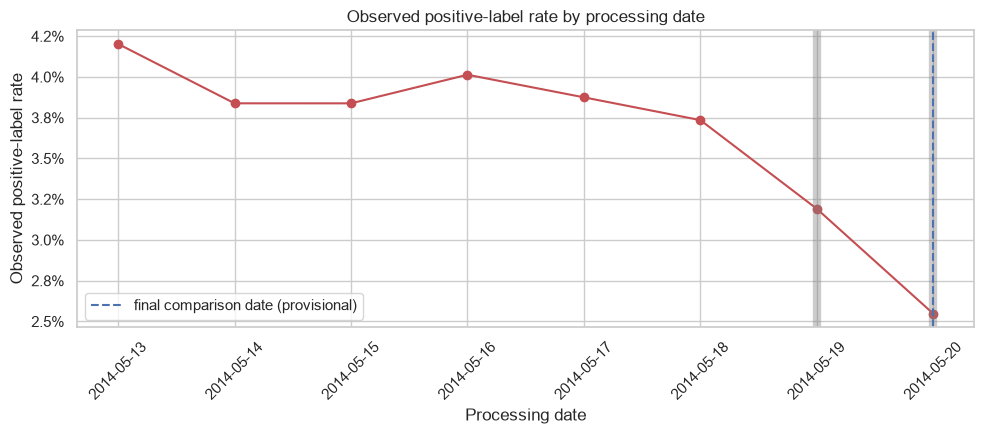

In [ ]:
daily = (
    raw.groupby("day")
    .agg(rows=(TARGET, "size"), calls=(TARGET, "sum"), call_rate=(TARGET, "mean"))
)
daily["weekday"] = [pd.Timestamp(day).day_name() for day in daily.index]
display(daily[["weekday", "rows", "calls", "call_rate"]].style.format({"call_rate": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily.index, daily["call_rate"], marker="o", color="#C44E52")
for day in LABEL_REVIEW_DAYS:
    if day in daily.index:
        ax.axvline(day, alpha=0.4, color="grey", linewidth=6)
ax.axvline(FINAL_TEST_DAY, color="#4C72B0", linestyle="--", label="final comparison date (provisional)")
ax.set_title("Observed positive-label rate by processing date")
ax.set_xlabel("Processing date")
ax.set_ylabel("Observed positive-label rate")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


Call rates fall on May 19 and May 20. This could reflect missing outcomes or a real change. We keep the supplied results, but their completeness must be confirmed before relying on the scores.


## Added features

We add three inputs: whether payment history is missing, Channel 4's share of payments, and whether the customer has logged in.

Missing values, numeric scaling, and category encoding are handled using training data only. Purchase channel is treated as a category, with values 0 and 1.


In [ ]:
SIX_MONTH_COLUMNS = [
    *[f"CHANNEL{i}_6M" for i in range(1, 6)],
    "METHOD1_6M", "PAYMENTS_6M", "RECENT_PAYMENT",
]


def add_engineered_features(frame):
    out = frame.copy()

    available_six_month = [c for c in SIX_MONTH_COLUMNS if c in out.columns]
    out["MISSING_6M_VALUES"] = out[available_six_month].isna().any(axis=1).astype(int)

    payments = out["PAYMENTS_6M"]
    channel_4 = out["CHANNEL4_6M"]
    out["CH4_SHARE_6M"] = np.where(
        payments.fillna(0) > 0,
        channel_4.fillna(0) / payments,
        0.0,
    )
    out["HAS_LOGIN"] = (out["LOGINS"].fillna(0) > 0).astype(int)
    return out


model_frame = add_engineered_features(raw)
feature_columns = [c for c in model_frame.columns if c not in NON_PREDICTOR_COLUMNS]

X_all = model_frame[feature_columns]
y_all = model_frame[TARGET]
day_all = model_frame["day"]

invalid_share = (~X_all["CH4_SHARE_6M"].between(0, 1)).mean()
print(f"Predictor columns before encoding: {len(feature_columns)}")
print(f"Rows with Channel 4 share outside [0, 1]: {invalid_share:.2%}")
if invalid_share > 0:
    print("Confirm that CHANNEL4_6M and PAYMENTS_6M use compatible definitions before deployment.")

Predictor columns before encoding: 29
Rows with Channel 4 share outside [0, 1]: 0.00%


In [ ]:
expected_days = set(DEVELOPMENT_DAYS + [FINAL_TEST_DAY] + LABEL_REVIEW_DAYS)
absent_days = sorted(expected_days.difference(set(day_all.unique())))
if absent_days:
    raise ValueError(f"Configured dates missing from the data: {absent_days}")


def eligible_training_days(candidate_days, scoring_day):
    scoring_date = pd.Timestamp(scoring_day)
    eligible = [
        day for day in candidate_days
        if pd.Timestamp(day) < scoring_date
        and pd.Timestamp(day) + pd.Timedelta(days=LABEL_AVAILABILITY_LAG_DAYS) <= scoring_date
    ]
    if not eligible:
        raise ValueError(
            f"No eligible training dates before {scoring_day} with a "
            f"{LABEL_AVAILABILITY_LAG_DAYS}-day label delay. Supply more historical data "
            "or revise the fold schedule; do not shorten a confirmed delay to make it run."
        )
    return eligible


ROLLING_FOLDS = [
    (eligible_training_days(train_days, validation_day), validation_day)
    for train_days, validation_day in ROLLING_FOLDS
]
display(pd.DataFrame([
    {"training_start": days[0], "training_end": days[-1], "validation_day": day,
     "label_delay_days": LABEL_AVAILABILITY_LAG_DAYS}
    for days, day in ROLLING_FOLDS
]))


def build_model(estimator, training_frame):
    categorical = [c for c in CATEGORICAL_COLUMNS if c in training_frame.columns]
    numeric = [c for c in training_frame.columns if c not in categorical]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
    ])

    try:
        one_hot = OneHotEncoder(
            handle_unknown="ignore", drop="first", sparse_output=False, dtype=np.float32
        )
    except TypeError:
        one_hot = OneHotEncoder(
            handle_unknown="ignore", drop="first", sparse=False, dtype=np.float32
        )

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", one_hot),
    ])

    preprocessing = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric),
        ("categorical", categorical_pipeline, categorical),
    ])

    return Pipeline([
        ("preprocessing", preprocessing),
        ("model", clone(estimator)),
    ])


,training_start,training_end,validation_day,label_delay_days
0,2014-05-13,2014-05-13,2014-05-19,6


## How performance is measured

**Capture at 10%:** the share of all actual callers found in the selected group.

**Precision at 10%:** the share of selected records that actually called.

**Lift at 10%:** the selected group's call rate divided by the overall call rate.


In [ ]:
def positive_scores(model, features):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    return model.decision_function(features)


def ranking_metrics(labels, scores, contact_rate=CONTACT_RATE):
    labels = np.asarray(labels)
    if labels.ndim != 1 or not len(labels) or not np.isin(labels, [0, 1]).all():
        raise ValueError("Labels must be a nonempty one-dimensional binary array.")
    labels = labels.astype(int)
    scores = np.asarray(scores, dtype=float)
    if scores.shape != labels.shape or not np.isfinite(scores).all():
        raise ValueError("Scores must be finite and have the same shape as labels.")
    if not 0 < contact_rate <= 1:
        raise ValueError("contact_rate must be in (0, 1].")
    n_contact = int(np.floor(contact_rate * len(labels)))
    if n_contact < 1:
        raise ValueError("The contact budget is too small to select one record.")
    selected = np.argsort(-scores, kind="stable")[:n_contact]

    positives = int(labels.sum())
    captured = int(labels[selected].sum())
    precision = captured / n_contact
    base_rate = labels.mean()

    return {
        "rows": len(labels),
        "customers_contacted": n_contact,
        "actual_contact_rate": n_contact / len(labels),
        "callers_captured": captured,
        "capture_at_10": captured / positives if positives else np.nan,
        "precision_at_10": precision,
        "lift_at_10": precision / base_rate if base_rate else np.nan,
        "roc_auc": roc_auc_score(labels, scores) if len(np.unique(labels)) == 2 else np.nan,
        "average_precision": (
            average_precision_score(labels, scores)
            if len(np.unique(labels)) == 2 else np.nan
        ),
    }


## Compare the models

Compare both models and the Channel 4 rule on the same May 19 records, using the same contact budget.

Training respects the six day wait. Model settings are unchanged. One validation date is not enough to establish a reliable winner.


In [ ]:
model_specs = {
    "Logistic Regression": LogisticRegression(
        C=0.1, max_iter=2_000, random_state=RANDOM_STATE
    ),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

backtest_rows = []

for fold_number, (train_days, validation_day) in enumerate(ROLLING_FOLDS, start=1):
    train_mask = day_all.isin(train_days)
    validation_mask = day_all.eq(validation_day)

    X_train = X_all.loc[train_mask]
    y_train = y_all.loc[train_mask]
    X_validation = X_all.loc[validation_mask]
    y_validation = y_all.loc[validation_mask]

    for model_name, estimator in model_specs.items():
        candidate = build_model(estimator, X_train)
        candidate.fit(X_train, y_train)
        scores = positive_scores(candidate, X_validation)
        metrics = ranking_metrics(y_validation, scores)
        backtest_rows.append({
            "fold": fold_number,
            "validation_day": validation_day,
            "model": model_name,
            **metrics,
        })

    rule_scores = X_validation["CHANNEL4_6M"].fillna(0).to_numpy()
    rule_metrics = ranking_metrics(y_validation, rule_scores)
    backtest_rows.append({
        "fold": fold_number,
        "validation_day": validation_day,
        "model": "Channel 4 activity rule",
        **rule_metrics,
    })

backtest = pd.DataFrame(backtest_rows)
display(
    backtest[[
        "validation_day", "model", "capture_at_10", "precision_at_10",
        "lift_at_10", "roc_auc", "average_precision",
    ]].style.format({
        "capture_at_10": "{:.2%}",
        "precision_at_10": "{:.2%}",
        "lift_at_10": "{:.2f}x",
        "roc_auc": "{:.3f}",
        "average_precision": "{:.3f}",
    })
)

,validation_day,model,capture_at_10,precision_at_10,lift_at_10,roc_auc,average_precision
0,2014-05-19,Logistic Regression,54.41%,17.37%,5.44x,0.850,0.201
1,2014-05-19,Histogram Gradient Boosting,55.35%,17.66%,5.54x,0.855,0.198
2,2014-05-19,Channel 4 activity rule,44.84%,14.31%,4.49x,0.751,0.139


,mean_capture_at_10,min_capture_at_10,mean_precision_at_10,mean_lift_at_10,mean_roc_auc
model,,,,,
Histogram Gradient Boosting,55.35%,55.35%,17.66%,5.54x,0.855
Logistic Regression,54.41%,54.41%,17.37%,5.44x,0.850
Channel 4 activity rule,44.84%,44.84%,14.31%,4.49x,0.751


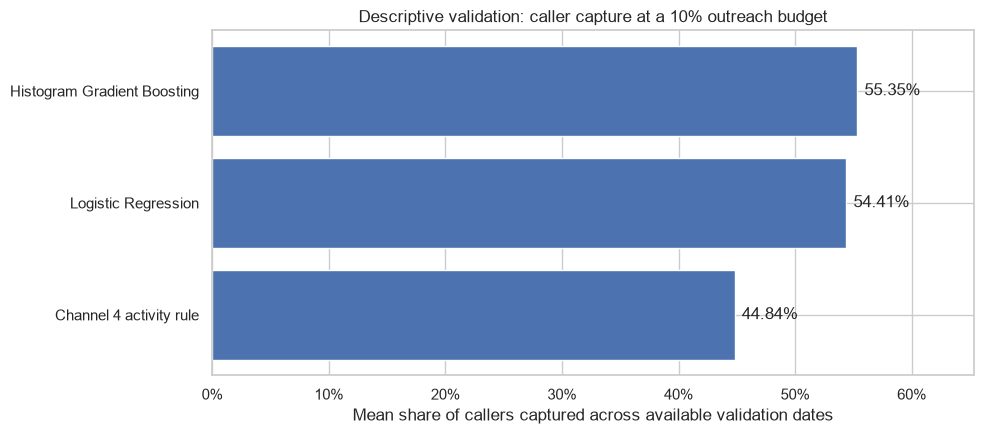

In [ ]:
backtest_summary = (
    backtest.groupby("model")
    .agg(
        mean_capture_at_10=("capture_at_10", "mean"),
        min_capture_at_10=("capture_at_10", "min"),
        mean_precision_at_10=("precision_at_10", "mean"),
        mean_lift_at_10=("lift_at_10", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
    )
    .sort_values("mean_capture_at_10", ascending=False)
)
display(backtest_summary.style.format({
    "mean_capture_at_10": "{:.2%}",
    "min_capture_at_10": "{:.2%}",
    "mean_precision_at_10": "{:.2%}",
    "mean_lift_at_10": "{:.2f}x",
    "mean_roc_auc": "{:.3f}",
}))


plot_summary = backtest_summary.sort_values("mean_capture_at_10")
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(plot_summary.index, plot_summary["mean_capture_at_10"], color="#4C72B0")
ax.bar_label(bars, labels=[f"{value:.2%}" for value in plot_summary["mean_capture_at_10"]], padding=5)
ax.set_xlim(0, min(1.05, plot_summary["mean_capture_at_10"].max() + 0.10))
ax.set_title("Descriptive validation: caller capture at a 10% outreach budget")
ax.set_xlabel("Mean share of callers captured across available validation dates")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()


## Keep the final model fixed

Use **Histogram Gradient Boosting** from the original notebook. The new results do not change its settings or selection.

May 19 outcomes would not be known by May 20, so they cannot choose that day's model. The comparison below shows performance on one date, not proof that one model is consistently better.

The original validation averages are not reused because their training dates did not allow enough time for outcomes to become known.


In [ ]:
model_names = list(model_specs)
model_validation = backtest_summary.loc[model_names].sort_values(
    ["mean_capture_at_10", "mean_roc_auc"], ascending=False
)
if PRESELECTED_MODEL_NAME not in model_specs:
    raise ValueError("The preselected model must be defined in model_specs.")
BEST_MODEL_NAME = PRESELECTED_MODEL_NAME
BEST_MODEL_SPEC = model_specs[BEST_MODEL_NAME]

print(f"Preselected model: {BEST_MODEL_NAME}")
print(f"Observed validation leader (descriptive only): {model_validation.index[0]}")
print(f"Preselected model's validation capture: {model_validation.loc[BEST_MODEL_NAME, 'mean_capture_at_10']:.2%}")
print("Validation outcomes are not used to change the model for May 20.")


Preselected model: Histogram Gradient Boosting
Observed validation leader (descriptive only): Histogram Gradient Boosting
Preselected model's validation capture: 55.35%
Validation outcomes are not used to change the model for May 20.


In [ ]:
paired_capture = backtest.pivot(index="validation_day", columns="model", values="capture_at_10")
boost_minus_logistic = (
    paired_capture["Histogram Gradient Boosting"] - paired_capture["Logistic Regression"]
)
fold_comparison = paired_capture[["Logistic Regression", "Histogram Gradient Boosting"]].copy()
fold_comparison["Boosting minus logistic (percentage points)"] = 100 * boost_minus_logistic
display(fold_comparison.style.format({
    "Logistic Regression": "{:.2%}",
    "Histogram Gradient Boosting": "{:.2%}",
    "Boosting minus logistic (percentage points)": "{:+.2f}",
}))
boost_wins = int((boost_minus_logistic > 1e-12).sum())
logistic_wins = int((boost_minus_logistic < -1e-12).sum())
ties = len(boost_minus_logistic) - boost_wins - logistic_wins
display(Markdown(
    f"Gradient boosting captures **{100 * boost_minus_logistic.mean():+.2f} percentage points** "
    f"more callers than logistic regression on average across "
    f"**{len(boost_minus_logistic)}** validation date(s). "
    "The final model stays fixed. More dates are needed to judge whether this advantage holds."
))

model,Logistic Regression,Histogram Gradient Boosting,Boosting minus logistic (percentage points)
validation_day,,,
2014-05-19,54.41%,55.35%,+0.94


Gradient boosting captures **+0.94 percentage points** more callers than logistic regression on average across **1** validation date(s). The final model stays fixed. More dates are needed to judge whether this advantage holds.

## Which inputs matter

Shuffle each input and measure how much ROC-AUC falls. A larger drop means the model relies more on that input.

This measures the overall ranking quality, not just the top 10%. Related payment inputs can affect each other's importance. These results do not show what causes calls.


,feature,importance_mean,importance_std
27,CH4_SHARE_6M,0.127202,0.005220
24,LOGINS,0.017731,0.004415
7,CHANNEL2_6M,0.014258,0.004284
2,Tenure,0.010520,0.004874
15,CHANNEL2_3M,0.007989,0.000961
21,NOT_DI_3M,0.005775,0.002046
13,PAYMENTS_6M,0.004327,0.001727
20,PAYMENTS_3M,0.004204,0.003617
12,RECENT_PAYMENT,0.003537,0.000279
10,CHANNEL5_6M,0.003311,0.000888


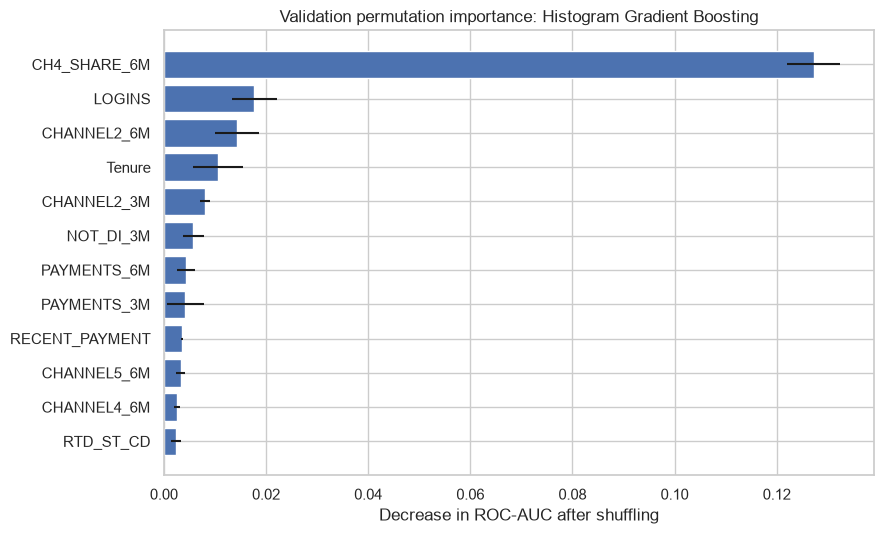

In [ ]:
explanation_train_days = ROLLING_FOLDS[-1][0]
explanation_day = ROLLING_FOLDS[-1][1]

explanation_train_mask = day_all.isin(explanation_train_days)
explanation_validation_mask = day_all.eq(explanation_day)

X_explain_train = X_all.loc[explanation_train_mask]
y_explain_train = y_all.loc[explanation_train_mask]
X_explain_validation = X_all.loc[explanation_validation_mask]
y_explain_validation = y_all.loc[explanation_validation_mask]

explanation_model = build_model(BEST_MODEL_SPEC, X_explain_train)
explanation_model.fit(X_explain_train, y_explain_train)

explanation_indices = X_explain_validation.sample(
    n=min(EXPLANATION_SAMPLE, len(X_explain_validation)),
    random_state=RANDOM_STATE,
).index

importance = permutation_importance(
    explanation_model,
    X_explain_validation.loc[explanation_indices],
    y_explain_validation.loc[explanation_indices],
    scoring="roc_auc",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,  # Avoid spawning many large copies of the fitted pipeline.
)

importance_table = (
    pd.DataFrame({
        "feature": X_explain_validation.columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

display(importance_table.head(15))

top_importance = importance_table.head(12).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    color="#4C72B0",
)
ax.set_title(f"Validation permutation importance: {BEST_MODEL_NAME}")
ax.set_xlabel("Decrease in ROC-AUC after shuffling")
plt.tight_layout()
plt.show()


## Final test

Train the fixed model on May 13 and May 14, then score May 20. Compare it with the Channel 4 rule at the same contact budget.

Results assume complete outcomes through May 25. This reuses existing project data, so it is not a new independent test. Do not adjust the model based on these results.


In [ ]:
final_train_days = eligible_training_days(DEVELOPMENT_DAYS, FINAL_TEST_DAY)
print("Final training dates:", ", ".join(final_train_days))
final_train_mask = day_all.isin(final_train_days)
final_test_mask = day_all.eq(FINAL_TEST_DAY)

X_final_train = X_all.loc[final_train_mask]
y_final_train = y_all.loc[final_train_mask]
X_final_test = X_all.loc[final_test_mask]
y_final_test = y_all.loc[final_test_mask]

final_model = build_model(BEST_MODEL_SPEC, X_final_train)
final_model.fit(X_final_train, y_final_train)

final_scores = positive_scores(final_model, X_final_test)
final_metrics = ranking_metrics(y_final_test, final_scores)

final_rule_scores = X_final_test["CHANNEL4_6M"].fillna(0).to_numpy()
final_rule_metrics = ranking_metrics(y_final_test, final_rule_scores)

final_comparison = pd.DataFrame(
    [final_metrics, final_rule_metrics],
    index=[BEST_MODEL_NAME, "Channel 4 activity rule"],
)
display(final_comparison[[
    "customers_contacted", "actual_contact_rate", "callers_captured", "capture_at_10",
    "precision_at_10", "lift_at_10", "roc_auc", "average_precision",
]].style.format({
    "actual_contact_rate": "{:.3%}",
    "capture_at_10": "{:.2%}",
    "precision_at_10": "{:.2%}",
    "lift_at_10": "{:.2f}x",
    "roc_auc": "{:.3f}",
    "average_precision": "{:.3f}",
}))


Final training dates: 2014-05-13, 2014-05-14


,customers_contacted,actual_contact_rate,callers_captured,capture_at_10,precision_at_10,lift_at_10,roc_auc,average_precision
Histogram Gradient Boosting,1499,9.997%,184,48.17%,12.27%,4.82x,0.839,0.135
Channel 4 activity rule,1499,9.997%,141,36.91%,9.41%,3.69x,0.719,0.084


## Ranked contact list

This list ranks past May 20 records. Before using it for outreach, add customer IDs and remove repeat contacts.


In [ ]:
n_contact = final_metrics["customers_contacted"]
score_order = np.argsort(-final_scores, kind="stable")
rank_position = np.empty(len(final_scores), dtype=int)
rank_position[score_order] = np.arange(1, len(final_scores) + 1)

ranked_contact_list = pd.DataFrame({
    "source_row": X_final_test.index,
    "processing_date": raw.loc[X_final_test.index, DATE_COLUMN].to_numpy(),
    "call_score": final_scores,
    "priority_rank": rank_position,
    "contact": rank_position <= n_contact,
}).sort_values("priority_rank")

display(ranked_contact_list.head(20))

# Optional export after a stable customer identifier is added:
# ranked_contact_list.to_csv("ranked_outreach_list.csv", index=False)

,source_row,processing_date,call_score,priority_rank,contact
311,2857,2014-05-20,0.697640,1,True
1010,8882,2014-05-20,0.691220,2,True
5189,45559,2014-05-20,0.687355,3,True
3843,33889,2014-05-20,0.674080,4,True
2424,21931,2014-05-20,0.672246,5,True
14222,124672,2014-05-20,0.667156,6,True
9187,81483,2014-05-20,0.664148,7,True
2406,21776,2014-05-20,0.657317,8,True
4994,43964,2014-05-20,0.656184,9,True
14681,128268,2014-05-20,0.652945,10,True


In [ ]:
capture_gain = final_metrics["capture_at_10"] - final_rule_metrics["capture_at_10"]

print("INSURANCE SERVICE CALL PRIORITIZATION — EXPLORATORY RESULTS")
print("=" * 62)
print(f"Final test date:                 {FINAL_TEST_DAY}")
print(f"Preselected model:                 {BEST_MODEL_NAME}")
print(f"Customers contacted:            {final_metrics['customers_contacted']:,} ({final_metrics['actual_contact_rate']:.3%})")
print(f"Callers captured:               {final_metrics['callers_captured']:,}")
print(f"Capture at 10%:                 {final_metrics['capture_at_10']:.2%}")
print(f"Call rate among contacted:      {final_metrics['precision_at_10']:.2%}")
print(f"Lift over random outreach:      {final_metrics['lift_at_10']:.2f}x")
print(f"ROC-AUC:                        {final_metrics['roc_auc']:.3f}")
print(f"Capture gain over Channel 4:    {100 * capture_gain:+.2f} percentage points")
print("=" * 62)


INSURANCE SERVICE CALL PRIORITIZATION — EXPLORATORY RESULTS
Final test date:                 2014-05-20
Preselected model:                 Histogram Gradient Boosting
Customers contacted:            1,499 (9.997%)
Callers captured:               184
Capture at 10%:                 48.17%
Call rate among contacted:      12.27%
Lift over random outreach:      4.82x
ROC-AUC:                        0.839
Capture gain over Channel 4:    +11.26 percentage points


## What the results mean


In [ ]:
additional_captured = final_metrics["callers_captured"] - final_rule_metrics["callers_captured"]
total_callers = int(y_final_test.sum())
test_date_text = pd.Timestamp(FINAL_TEST_DAY).strftime("%B %d, %Y")
display(Markdown(
    f"On **{test_date_text}**, **{BEST_MODEL_NAME}** finds "
    f"**{final_metrics['callers_captured']:,} of {total_callers:,} callers "
    f"({final_metrics['capture_at_10']:.2%})** in the top "
    f"**{final_metrics['customers_contacted']:,} records**. "
    f"The Channel 4 rule finds **{final_rule_metrics['callers_captured']:,}** at the same contact budget. "
    f"That is a difference of **{additional_captured:+,} callers** and "
    f"**{100 * capture_gain:+.2f} percentage points** of capture.\n\n"
    "These results assume complete call records. They show who the model identifies, "
    "not whether an email prevents calls. Confirm the data, test more dates, and run a small email experiment."
))

On **May 20, 2014**, **Histogram Gradient Boosting** finds **184 of 382 callers (48.17%)** in the top **1,499 records**. The Channel 4 rule finds **141** at the same contact budget. That is a difference of **+43 callers** and **+11.26 percentage points** of capture.

These results assume complete call records. They show who the model identifies, not whether an email prevents calls. Confirm the data, test more dates, and run a small email experiment.

## Next steps

1. Confirm complete outcomes for May 19 and May 20, including any reporting delay.
2. Check that every input was available before scoring.
3. Add customer IDs to identify repeat records and avoid duplicate contacts.
4. Compare models over more weeks or months. Finish model selection before the test period begins.
5. Randomly assign eligible customers to receive an email or no email. Measure calls avoided and contact costs.
